#  Ex1 Linear Regression: synthetic data


In [1]:
import torch
import numpy as np
from matplotlib import pyplot as plt
import torch.nn as nn
import torch.optim as opt

In [2]:
N= 30

In [3]:
#rand (-5,5)
X = np.random.rand(N)*10-5

In [4]:
y = 0.5 *X +(np.random.randn(N) - 1)

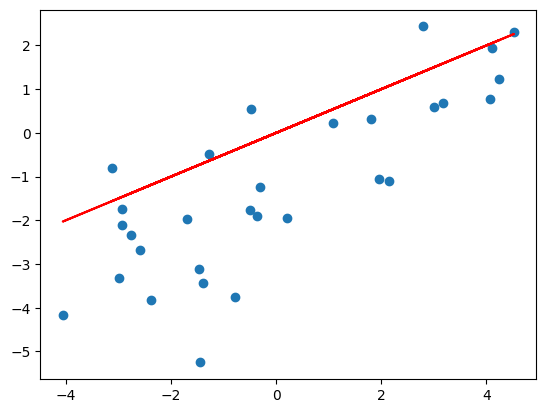

In [5]:
plt.scatter(X,y)
plt.plot(X,0.5 *X ,color='red')
plt.show()

## Building the model ##

In [6]:
model = nn.Linear(1,1)
criterion = nn.MSELoss()
optimizer = opt.SGD(model.parameters(),lr=0.01)

## reshape X,y to match samples and convert to tensors

In [7]:
X = X.reshape(N,1)
y = y.reshape(N,1)
if torch.cuda.is_available():
    print("CUDA")
    inputs = torch.from_numpy(X.astype(np.float32)).cuda()
    targets = torch.from_numpy(y.astype(np.float32)).cuda()

    model = model.cuda()
    criterion = criterion.cuda()
else:
    print("CPU")
    inputs = torch.from_numpy(X.astype(np.float32))
    targets = torch.from_numpy(y.astype(np.float32))   

CUDA


## training loop

In [8]:
EPOCHS = 75

losses = []
for epoch in range(EPOCHS):
    optimizer.zero_grad()

    predictions = model(inputs)
    loss = criterion(targets,predictions)
    losses.append(loss.item())
    loss.backward()
    optimizer.step()
    print(f'epoch {epoch+1}/{EPOCHS}: Loss {loss.item():.4f}')

epoch 1/75: Loss 2.1972
epoch 2/75: Loss 2.1506
epoch 3/75: Loss 2.1097
epoch 4/75: Loss 2.0735
epoch 5/75: Loss 2.0409
epoch 6/75: Loss 2.0113
epoch 7/75: Loss 1.9841
epoch 8/75: Loss 1.9590
epoch 9/75: Loss 1.9356
epoch 10/75: Loss 1.9137
epoch 11/75: Loss 1.8931
epoch 12/75: Loss 1.8736
epoch 13/75: Loss 1.8551
epoch 14/75: Loss 1.8375
epoch 15/75: Loss 1.8208
epoch 16/75: Loss 1.8048
epoch 17/75: Loss 1.7896
epoch 18/75: Loss 1.7750
epoch 19/75: Loss 1.7610
epoch 20/75: Loss 1.7476
epoch 21/75: Loss 1.7348
epoch 22/75: Loss 1.7225
epoch 23/75: Loss 1.7106
epoch 24/75: Loss 1.6993
epoch 25/75: Loss 1.6884
epoch 26/75: Loss 1.6780
epoch 27/75: Loss 1.6680
epoch 28/75: Loss 1.6584
epoch 29/75: Loss 1.6492
epoch 30/75: Loss 1.6403
epoch 31/75: Loss 1.6318
epoch 32/75: Loss 1.6236
epoch 33/75: Loss 1.6158
epoch 34/75: Loss 1.6082
epoch 35/75: Loss 1.6010
epoch 36/75: Loss 1.5940
epoch 37/75: Loss 1.5874
epoch 38/75: Loss 1.5809
epoch 39/75: Loss 1.5748
epoch 40/75: Loss 1.5689
epoch 41/

## predict

In [9]:
predictions = model(inputs)

In [10]:
predictions1 = predictions.cpu().detach().numpy()

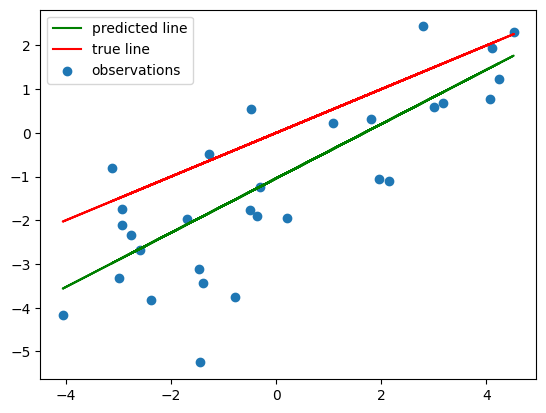

In [11]:
plt.plot(X,predictions1,color='green',label="predicted line")
plt.plot(X, 0.5 *X,color='red',label='true line')
plt.scatter(X,y,label='observations')
plt.legend(loc="upper left")

another option to predict is using torch.no_grad() to avoid calling detach

In [12]:
with torch.no_grad():
    out = model(inputs)
    print(out.cpu().numpy())

[[-1.3378637 ]
 [ 0.07620642]
 [-1.2665801 ]
 [ 0.2986594 ]
 [-1.3543366 ]
 [ 0.93395096]
 [-1.9468559 ]
 [ 0.17039722]
 [-1.2277125 ]
 [ 0.8293041 ]
 [-1.9071848 ]
 [-2.9857461 ]
 [-2.0886443 ]
 [-2.6494813 ]
 [-0.90793484]
 [-2.7528164 ]
 [ 1.7664016 ]
 [-2.89962   ]
 [-1.9351189 ]
 [ 1.4813042 ]
 [-1.5244842 ]
 [-2.520817  ]
 [-3.5622842 ]
 [ 1.5045717 ]
 [ 1.5954691 ]
 [-2.8567348 ]
 [-2.8677163 ]
 [ 0.697753  ]
 [-0.3744674 ]
 [-1.8292747 ]]


## let's plot the loss

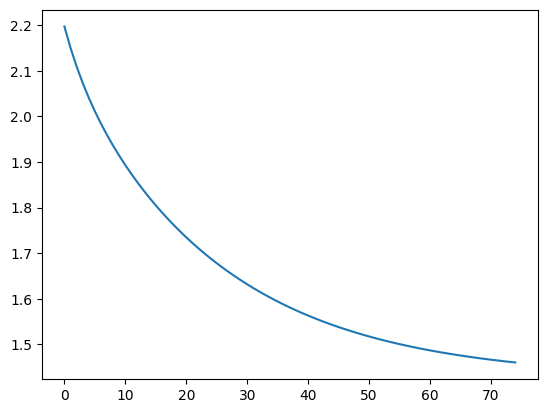

In [13]:
plt.plot([i for i in range(len(losses))],losses)


as we can see we should set EPOCHS to 75 beyond that we don't really learn much

## let's extract our weights and bias

In [14]:
w = model.weight.cpu().data.numpy()
b = model.bias.cpu().data.numpy()
print(f'weight {w}X+{b}')

weight [[0.62132156]]X+[-1.0411923]
